<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter04/02-图像的特征提取.ipynb" target="_blank"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn

### 1 识别图像边缘

In [2]:
X = torch.ones((6, 8))
X[:, 2:6] = 0
X = X.reshape((1, 1, 6, 8))
X

tensor([[[[1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.],
          [1., 1., 0., 0., 0., 0., 1., 1.]]]])

In [3]:
conv = nn.Conv2d(1,1, kernel_size=(1, 2), bias=False)
print(conv.weight.data)
# 卷积层的权重是一个四维张量，其形状为
#  (out_channels, in_channels, kernel_height, kernel_width)
conv.weight.data=torch.tensor([[[[1.,  -1.]]]],dtype=torch.float32)
Y=conv(X)
print(Y)

tensor([[[[0.4815, 0.2004]]]])
tensor([[[[ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.],
          [ 0.,  1.,  0.,  0.,  0., -1.,  0.]]]],
       grad_fn=<ConvolutionBackward0>)


### 2 通过训练学习到 kernel

In [4]:
# 构造一个二维卷积层，它具有1个输出通道和形状为（1，2）的卷积核
conv2d = nn.Conv2d(1,1, kernel_size=(1, 2), bias=False)

# 这个二维卷积层使用四维输入和输出格式（批量大小、通道、高度、宽度），
# 其中批量大小和通道数都为1
X = X.reshape((1, 1, 6, 8))
Y = Y.reshape((1, 1, 6, 7))
lr = 3e-2  # 学习率

for i in range(10):
    Y_hat = conv2d(X)
    l = (Y_hat - Y) ** 2
    conv2d.zero_grad()
    l.sum().backward(retain_graph=True)
    # 迭代卷积核
    conv2d.weight.data[:] -= lr * conv2d.weight.grad
    if (i + 1) % 2 == 0:
        print(f'epoch {i+1}, loss {l.sum():.3f}')

print(conv2d.weight.data)

epoch 2, loss 12.798
epoch 4, loss 2.152
epoch 6, loss 0.363
epoch 8, loss 0.062
epoch 10, loss 0.011
tensor([[[[ 0.9790, -0.9838]]]])


### 3 使用sobel检测图片边缘

In [5]:
from PIL import Image
import matplotlib.pyplot as plt
import torch.nn.functional as F
import numpy as np

In [6]:
image = Image.open("../datasets/imagenet-sample-images-master/n01558993_robin.JPEG").convert('L')  #灰度图
image_color = Image.open("../datasets/imagenet-sample-images-master/n01558993_robin.JPEG")  #彩色图

conv = nn.Conv2d(1,1,3,bias=False)
# Sobel
# conv.weight.data=torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]],dtype=torch.float32).view(1,1,3,3)
# Scharr
conv.weight.data=torch.tensor([[-3,0,3],[-10,0,10],[-3,0,3]],dtype=torch.float32).view(1,1,3,3)

image_tensor = torch.from_numpy(np.array(image)).float().unsqueeze(0).unsqueeze(0)

filter_tensor=conv(image_tensor)


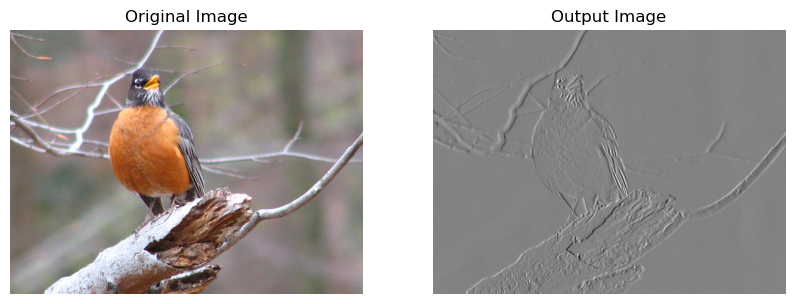

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# 显示原始图像
ax = axes[0]
ax.imshow(image_color)
ax.set_title('Original Image')
ax.axis('off')
 
    
# 显示卷积后的图像
ax = axes[1]
ax.imshow(filter_tensor.squeeze().detach().numpy(), cmap='gray')
ax.set_title('Output Image')
ax.axis('off')

plt.show()

### 4 显示图像三个通道的直方图特征

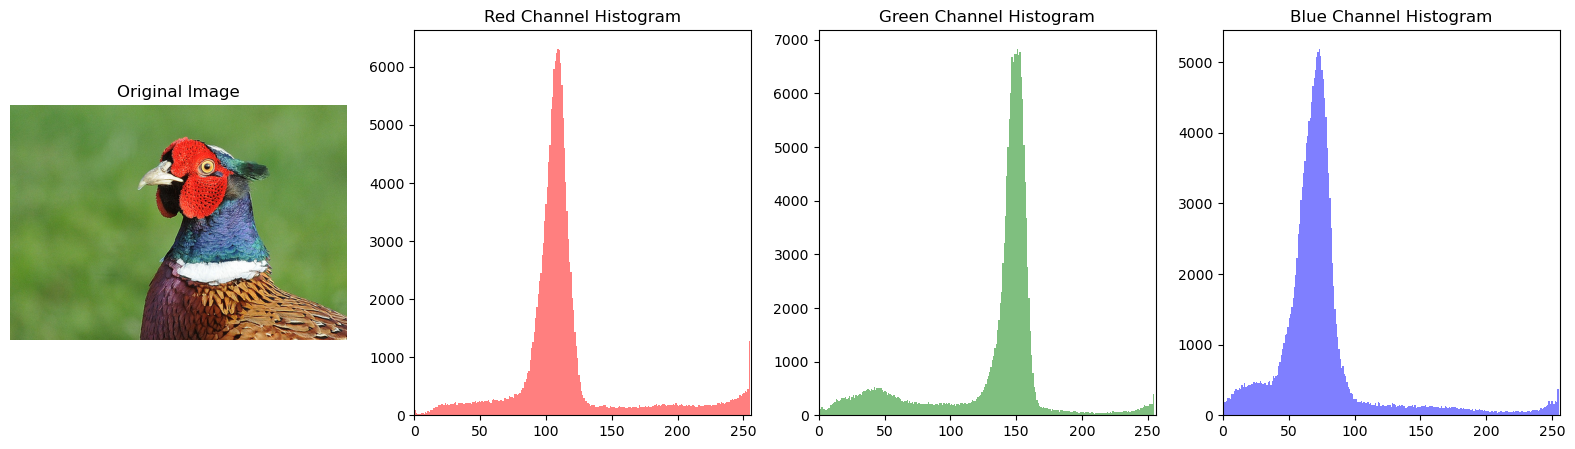

In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 加载图像
image_path = "../datasets/imagenet-sample-images-master/n01514668_cock.JPEG"
image = Image.open(image_path)

# 将图像转换为 NumPy 数组
image_array = np.array(image)

# 分离三个通道
red_channel = image_array[:, :, 0]
green_channel = image_array[:, :, 1]
blue_channel = image_array[:, :, 2]

# 创建图形和子图
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# 显示原始图像
axs[0].imshow(image)
axs[0].set_title('Original Image')
axs[0].axis('off')

# 绘制红色通道直方图
axs[1].hist(red_channel.ravel(), bins=256, color='red', alpha=0.5)
axs[1].set_title('Red Channel Histogram')
axs[1].set_xlim([0, 256])

# 绘制绿色通道直方图
axs[2].hist(green_channel.ravel(), bins=256, color='green', alpha=0.5)
axs[2].set_title('Green Channel Histogram')
axs[2].set_xlim([0, 256])

# 绘制蓝色通道直方图
axs[3].hist(blue_channel.ravel(), bins=256, color='blue', alpha=0.5)
axs[3].set_title('Blue Channel Histogram')
axs[3].set_xlim([0, 256])

# 显示图形
plt.show()

### 5 显示图像的边角特征

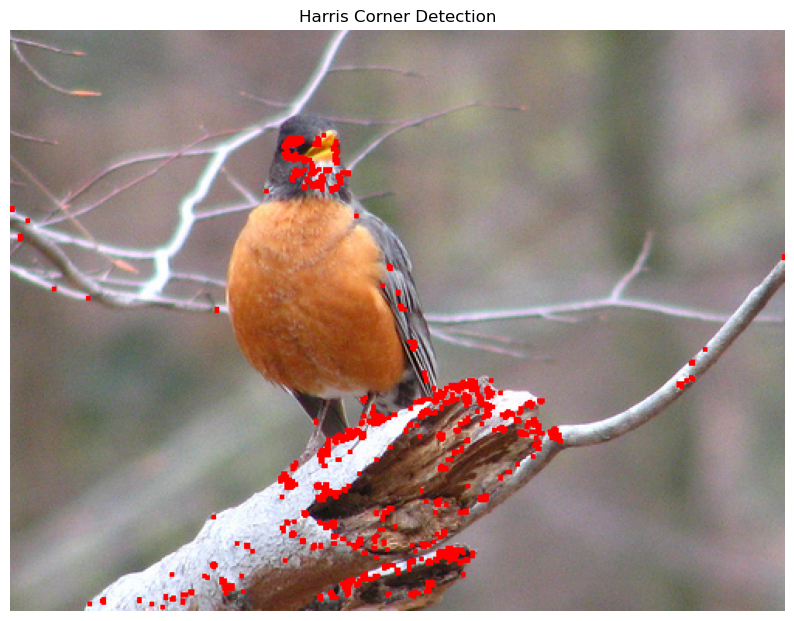

In [9]:
# 显示图像的边角特征
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 加载图像
image_path = "../datasets/imagenet-sample-images-master/n01558993_robin.JPEG"
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 使用 Harris 角点检测器
gray = np.float32(gray)
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# 结果进行膨胀以便于标记
dst = cv2.dilate(dst, None)

# 设定阈值，找到角点
threshold = 0.01 * dst.max()
image[dst > threshold] = [0, 0, 255]  # 用红色标记角点

# 显示结果
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corner Detection')
plt.axis('off')
plt.show()

### 6 色彩分离特征

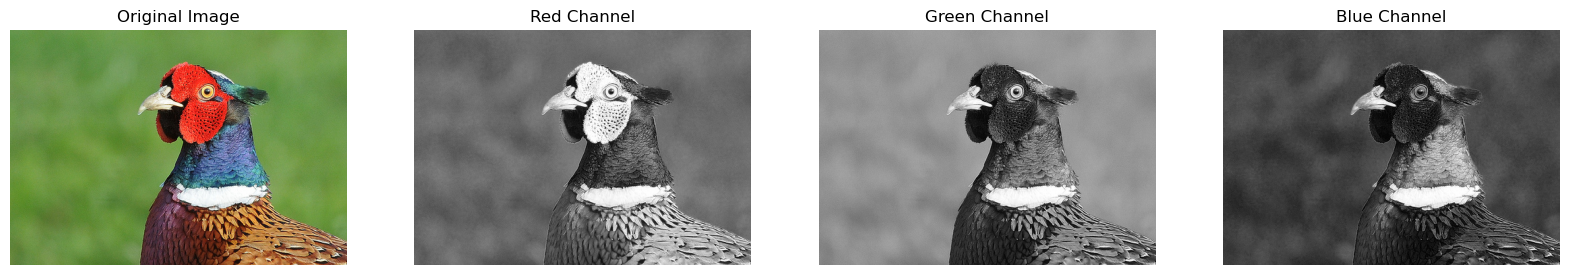

In [10]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 加载图像
image_path = "../datasets/imagenet-sample-images-master/n01514668_cock.JPEG"
image = Image.open(image_path)

# 将图像转换为 NumPy 数组
image_array = np.array(image)

# 分离三个通道
red_channel = image_array[:, :, 0]
green_channel = image_array[:, :, 1]
blue_channel = image_array[:, :, 2]

# 创建图形和子图
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

# 显示原始图像
axs[0].imshow(image)
axs[0].set_title('Original Image')
axs[0].axis('off')

# 显示红色通道图像
axs[1].imshow(red_channel, cmap='gray')  #Reds
axs[1].set_title('Red Channel')
axs[1].axis('off')

# 显示绿色通道图像
axs[2].imshow(green_channel, cmap='gray') #Greens
axs[2].set_title('Green Channel')
axs[2].axis('off')

# 显示蓝色通道图像
axs[3].imshow(blue_channel, cmap='gray') #Blues
axs[3].set_title('Blue Channel')
axs[3].axis('off')

# 显示图形
plt.show()

### 7 梯度特征

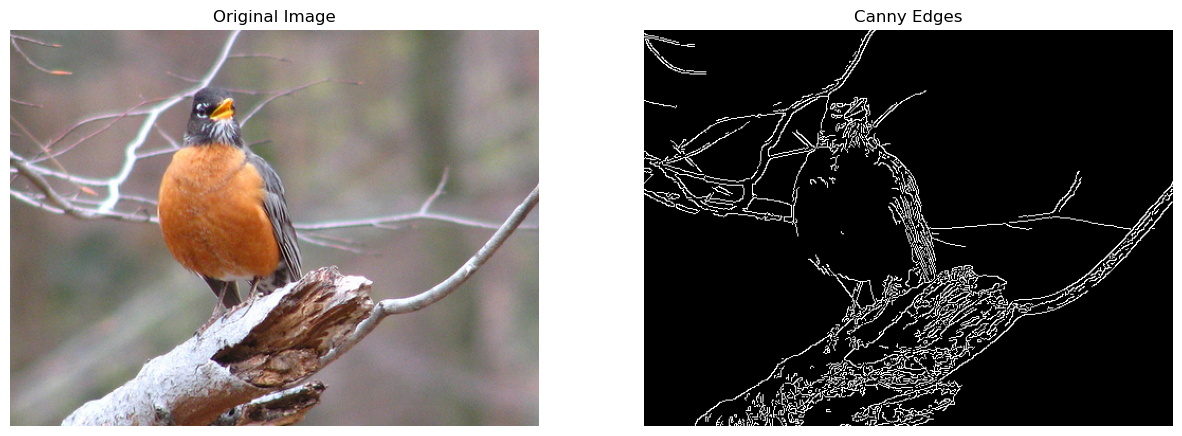

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 加载图像
image_path = "../datasets/imagenet-sample-images-master/n01558993_robin.JPEG"
image = cv2.imread(image_path)
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# 使用 Canny 边缘检测器
edges = cv2.Canny(gray, 100, 200)

# 创建图形和子图
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

# 显示原始图像
axs[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axs[0].set_title('Original Image')
axs[0].axis('off')

# 显示 Canny 边缘检测结果
axs[1].imshow(edges, cmap='gray')
axs[1].set_title('Canny Edges')
axs[1].axis('off')

# 显示图形
plt.show()